In [ ]:
# ============================================================
# 1) Install dependencies
# ============================================================
!pip install -q aeon torch scikit-learn matplotlib numpy pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 41.9 MB/s eta 0:00:00


In [ ]:
# ============================================================
# 2) Imports
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from copy import deepcopy
from dataclasses import dataclass

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from aeon.datasets import load_classification
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score

In [ ]:
# ============================================================
# 3) Global config
# ============================================================
CONFIG = {
    "target_length": 150,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "hidden_dim": 64,
    "num_classes": 2,
    "lr": 1e-3,
    "batch_size": 16,
    "epochs": 30,
    "ewc_lambda": 200.0,
    "lwf_alpha": 1.0,
    "lwf_temperature": 2.0,
    "replay_per_class": 100,
    "tsfd_alpha_logits": 1.0,
    "tsfd_alpha_features": 0.5,
    "tsfd_temperature": 2.0,
    "proto_memory_per_class": 20,
    "proto_alpha": 0.5,
}

SEQUENCES = [
    ["GunPoint", "SonyAIBORobotSurface1"],
    ["GunPoint", "ItalyPowerDemand"],
    ["SonyAIBORobotSurface1", "SonyAIBORobotSurface2"],
]

SEEDS = [0, 1, 2, 3, 4]

device = torch.device(CONFIG["device"])
print("Using device:", device)

Using device: cpu


In [ ]:
# ============================================================
# 4) Utilities
# ============================================================
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def resize_1d_series(x, target_length):
    old_idx = np.linspace(0, 1, len(x))
    new_idx = np.linspace(0, 1, target_length)
    return np.interp(new_idx, old_idx, x).astype(np.float32)

def make_loader(X, y, batch_size=16, shuffle=True):
    X_t = torch.tensor(X, dtype=torch.float32)
    y_t = torch.tensor(y, dtype=torch.long)
    ds = TensorDataset(X_t, y_t)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

def accuracy(model, loader, device):
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            pred = torch.argmax(logits, dim=1)
            preds.extend(pred.cpu().numpy())
            targets.extend(yb.cpu().numpy())
    return accuracy_score(targets, preds)

In [ ]:
# ============================================================
# 5) Task abstraction
# ============================================================
@dataclass
class TimeSeriesTask:
    name: str
    X_train: np.ndarray
    y_train: np.ndarray
    X_test: np.ndarray
    y_test: np.ndarray

class AeonTaskLoader:
    def __init__(self, target_length=150, only_first_channel=True):
        self.target_length = target_length
        self.only_first_channel = only_first_channel

    def load_task(self, dataset_name):
        X_train, y_train = load_classification(dataset_name, split="train")
        X_test, y_test = load_classification(dataset_name, split="test")

        if X_train.ndim == 3:
            if self.only_first_channel:
                X_train = X_train[:, 0, :]
                X_test = X_test[:, 0, :]
            else:
                raise ValueError("Multivariate handling not implemented yet.")
        elif X_train.ndim != 2:
            raise ValueError(f"Unexpected shape for {dataset_name}: {X_train.shape}")

        X_train = np.array([resize_1d_series(x, self.target_length) for x in X_train], dtype=np.float32)
        X_test = np.array([resize_1d_series(x, self.target_length) for x in X_test], dtype=np.float32)

        le = LabelEncoder()
        y_train = le.fit_transform(y_train)
        y_test = le.transform(y_test)

        n_classes = len(np.unique(y_train))
        if n_classes != 2:
            raise ValueError(f"{dataset_name} is not binary. Found {n_classes} classes.")

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train).astype(np.float32)
        X_test = scaler.transform(X_test).astype(np.float32)

        return TimeSeriesTask(
            name=dataset_name,
            X_train=X_train,
            y_train=y_train,
            X_test=X_test,
            y_test=y_test
        )

    def load_sequence(self, dataset_names):
        return [self.load_task(name) for name in dataset_names]

In [ ]:
# ============================================================
# 6) Models
# ============================================================
class FeatureMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_classes=2):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, num_classes)

    def extract_features(self, x):
        return self.relu(self.fc1(x))

    def forward(self, x):
        feats = self.extract_features(x)
        logits = self.fc2(feats)
        return logits

In [ ]:
# ============================================================
# 7) Base continual learning strategy
# ============================================================
class BaseStrategy:
    def __init__(self, model, device, lr=1e-3, batch_size=16, epochs=30):
        self.model = model.to(device)
        self.device = device
        self.lr = lr
        self.batch_size = batch_size
        self.epochs = epochs
        self.optimizer = optim.Adam(self.model.parameters(), lr=self.lr)
        self.ce_loss = nn.CrossEntropyLoss()

    def train_epoch(self, loader, extra_loss_fn=None):
        self.model.train()
        for xb, yb in loader:
            xb, yb = xb.to(self.device), yb.to(self.device)

            self.optimizer.zero_grad()
            logits = self.model(xb)
            loss = self.ce_loss(logits, yb)

            if extra_loss_fn is not None:
                extra = extra_loss_fn(xb, yb, logits)
                if isinstance(extra, (int, float)):
                    extra = torch.tensor(extra, dtype=torch.float32, device=self.device)
                loss = loss + extra

            loss.backward()
            self.optimizer.step()

    def fit_task(self, task, task_id=None):
        loader = make_loader(task.X_train, task.y_train, batch_size=self.batch_size, shuffle=True)
        for _ in range(self.epochs):
            self.train_epoch(loader)

    def evaluate_task(self, task):
        loader = make_loader(task.X_test, task.y_test, batch_size=self.batch_size, shuffle=False)
        return accuracy(self.model, loader, self.device)

In [ ]:
# ============================================================
# 8) Baseline strategy
# ============================================================
class BaselineStrategy(BaseStrategy):
    pass

In [ ]:
# ============================================================
# 9) EWC strategy
# ============================================================
class EWCStrategy(BaseStrategy):
    def __init__(self, model, device, lr=1e-3, batch_size=16, epochs=30, ewc_lambda=200.0):
        super().__init__(model, device, lr, batch_size, epochs)
        self.ewc_lambda = ewc_lambda
        self.fisher = None
        self.old_params = None

    def compute_fisher(self, task):
        loader = make_loader(task.X_train, task.y_train, batch_size=self.batch_size, shuffle=True)
        fisher = {n: torch.zeros_like(p) for n, p in self.model.named_parameters()}

        self.model.eval()
        for xb, yb in loader:
            xb, yb = xb.to(self.device), yb.to(self.device)
            self.model.zero_grad()
            logits = self.model(xb)
            loss = self.ce_loss(logits, yb)
            loss.backward()

            for n, p in self.model.named_parameters():
                if p.grad is not None:
                    fisher[n] += p.grad.detach() ** 2

        for n in fisher:
            fisher[n] /= len(loader)

        return fisher

    def save_old_params(self):
        self.old_params = {n: p.detach().clone() for n, p in self.model.named_parameters()}

    def ewc_penalty(self):
        if self.fisher is None or self.old_params is None:
            return torch.tensor(0.0, device=self.device)

        penalty = torch.tensor(0.0, device=self.device)
        for n, p in self.model.named_parameters():
            penalty += (self.fisher[n] * (p - self.old_params[n]) ** 2).sum()
        return 0.5 * self.ewc_lambda * penalty

    def fit_task(self, task, task_id=None):
        loader = make_loader(task.X_train, task.y_train, batch_size=self.batch_size, shuffle=True)

        if task_id == 0:
            for _ in range(self.epochs):
                self.train_epoch(loader)
        else:
            def extra_loss_fn(xb, yb, logits):
                return self.ewc_penalty()

            for _ in range(self.epochs):
                self.train_epoch(loader, extra_loss_fn=extra_loss_fn)

        self.fisher = self.compute_fisher(task)
        self.save_old_params()

In [ ]:
# ============================================================
# 10) LwF strategy
# ============================================================
class LwFStrategy(BaseStrategy):
    def __init__(self, model, device, lr=1e-3, batch_size=16, epochs=30, alpha=1.0, temperature=2.0):
        super().__init__(model, device, lr, batch_size, epochs)
        self.alpha = alpha
        self.temperature = temperature
        self.teacher = None
        self.kl = nn.KLDivLoss(reduction="batchmean")

    def distillation_loss(self, xb, logits):
        if self.teacher is None:
            return torch.tensor(0.0, device=self.device)

        with torch.no_grad():
            teacher_logits = self.teacher(xb)

        student_log_probs = torch.log_softmax(logits / self.temperature, dim=1)
        teacher_probs = torch.softmax(teacher_logits / self.temperature, dim=1)
        return self.alpha * self.kl(student_log_probs, teacher_probs) * (self.temperature ** 2)

    def fit_task(self, task, task_id=None):
        loader = make_loader(task.X_train, task.y_train, batch_size=self.batch_size, shuffle=True)

        if task_id == 0:
            for _ in range(self.epochs):
                self.train_epoch(loader)
        else:
            def extra_loss_fn(xb, yb, logits):
                return self.distillation_loss(xb, logits)

            for _ in range(self.epochs):
                self.train_epoch(loader, extra_loss_fn=extra_loss_fn)

        self.teacher = deepcopy(self.model).to(self.device)
        self.teacher.eval()

In [ ]:
# ============================================================
# 11) Replay strategy
# ============================================================
class ReplayStrategy(BaseStrategy):
    def __init__(self, model, device, lr=1e-3, batch_size=16, epochs=30, replay_per_class=100):
        super().__init__(model, device, lr, batch_size, epochs)
        self.replay_per_class = replay_per_class
        self.replay_stats = None

    def fit_class_gaussians(self, X, y):
        stats = {}
        for c in np.unique(y):
            Xc = X[y == c]
            mean = Xc.mean(axis=0)
            var = Xc.var(axis=0) + 1e-4
            stats[c] = (mean, var)
        return stats

    def sample_replay(self):
        Xs, ys = [], []
        for c, (mean, var) in self.replay_stats.items():
            samples = np.random.randn(self.replay_per_class, len(mean)) * np.sqrt(var) + mean
            Xs.append(samples.astype(np.float32))
            ys.append(np.full(self.replay_per_class, c))
        return np.vstack(Xs), np.concatenate(ys)

    def fit_task(self, task, task_id=None):
        if task_id == 0:
            loader = make_loader(task.X_train, task.y_train, batch_size=self.batch_size, shuffle=True)
            for _ in range(self.epochs):
                self.train_epoch(loader)
            self.replay_stats = self.fit_class_gaussians(task.X_train, task.y_train)
        else:
            X_replay, y_replay = self.sample_replay()
            X_mix = np.vstack([task.X_train, X_replay]).astype(np.float32)
            y_mix = np.concatenate([task.y_train, y_replay])

            loader = make_loader(X_mix, y_mix, batch_size=self.batch_size, shuffle=True)
            for _ in range(self.epochs):
                self.train_epoch(loader)

            self.replay_stats = self.fit_class_gaussians(X_mix, y_mix)

In [ ]:
# ============================================================
# 12) TS-FeatureDistill strategy
# ============================================================
class TSFeatureDistillStrategy(BaseStrategy):
    def __init__(
        self,
        model,
        device,
        lr=1e-3,
        batch_size=16,
        epochs=30,
        alpha_logits=1.0,
        alpha_features=1.0,
        temperature=2.0,
    ):
        super().__init__(model, device, lr, batch_size, epochs)
        self.alpha_logits = alpha_logits
        self.alpha_features = alpha_features
        self.temperature = temperature
        self.teacher = None
        self.kl = nn.KLDivLoss(reduction="batchmean")
        self.mse = nn.MSELoss()

    def distill_loss(self, xb, logits):
        if self.teacher is None:
            return torch.tensor(0.0, device=self.device)

        with torch.no_grad():
            teacher_logits = self.teacher(xb)
            teacher_feats = self.teacher.extract_features(xb)

        student_log_probs = torch.log_softmax(logits / self.temperature, dim=1)
        teacher_probs = torch.softmax(teacher_logits / self.temperature, dim=1)
        logit_loss = self.kl(student_log_probs, teacher_probs) * (self.temperature ** 2)

        student_feats = self.model.extract_features(xb)
        feat_loss = self.mse(student_feats, teacher_feats)

        return self.alpha_logits * logit_loss + self.alpha_features * feat_loss

    def fit_task(self, task, task_id=None):
        loader = make_loader(task.X_train, task.y_train, batch_size=self.batch_size, shuffle=True)

        if task_id == 0:
            for _ in range(self.epochs):
                self.train_epoch(loader)
        else:
            def extra_loss_fn(xb, yb, logits):
                return self.distill_loss(xb, logits)

            for _ in range(self.epochs):
                self.train_epoch(loader, extra_loss_fn=extra_loss_fn)

        self.teacher = deepcopy(self.model).to(self.device)
        self.teacher.eval()

In [ ]:
# ============================================================
# 13) TS-ProtoReplay strategy
# ============================================================
class TSProtoReplayStrategy(BaseStrategy):
    def __init__(
        self,
        model,
        device,
        lr=1e-3,
        batch_size=16,
        epochs=30,
        memory_per_class=20,
        alpha_proto=1.0,
    ):
        super().__init__(model, device, lr, batch_size, epochs)
        self.memory_per_class = memory_per_class
        self.alpha_proto = alpha_proto
        self.memory_X = []
        self.memory_y = []
        self.prototypes = {}
        self.mse = nn.MSELoss()

    def update_memory(self, X, y):
        mem_X, mem_y = [], []
        classes = np.unique(y)

        for c in classes:
            Xc = X[y == c]
            n = min(self.memory_per_class, len(Xc))
            idx = np.random.choice(len(Xc), size=n, replace=False)
            mem_X.append(Xc[idx])
            mem_y.append(np.full(n, c))

        mem_X = np.vstack(mem_X).astype(np.float32)
        mem_y = np.concatenate(mem_y)

        self.memory_X.append(mem_X)
        self.memory_y.append(mem_y)

    def get_memory(self):
        if len(self.memory_X) == 0:
            return None, None
        X_mem = np.vstack(self.memory_X).astype(np.float32)
        y_mem = np.concatenate(self.memory_y)
        return X_mem, y_mem

    def update_prototypes(self):
        X_mem, y_mem = self.get_memory()
        if X_mem is None:
            return

        self.model.eval()
        X_t = torch.tensor(X_mem, dtype=torch.float32).to(self.device)
        y_t = torch.tensor(y_mem, dtype=torch.long).to(self.device)

        with torch.no_grad():
            feats = self.model.extract_features(X_t)

        self.prototypes = {}
        for c in torch.unique(y_t):
            mask = y_t == c
            proto = feats[mask].mean(dim=0)
            self.prototypes[int(c.item())] = proto.detach().clone()

    def prototype_loss(self, xb, yb):
        if len(self.prototypes) == 0:
            return torch.tensor(0.0, device=self.device)

        feats = self.model.extract_features(xb)
        loss = torch.tensor(0.0, device=self.device)
        count = 0

        for c, proto in self.prototypes.items():
            mask = (yb == c)
            if mask.sum() > 0:
                loss += self.mse(feats[mask].mean(dim=0), proto.to(self.device))
                count += 1

        if count == 0:
            return torch.tensor(0.0, device=self.device)
        return self.alpha_proto * loss / count

    def fit_task(self, task, task_id=None):
        if task_id == 0:
            loader = make_loader(task.X_train, task.y_train, batch_size=self.batch_size, shuffle=True)
            for _ in range(self.epochs):
                self.train_epoch(loader)

            self.update_memory(task.X_train, task.y_train)
            self.update_prototypes()
        else:
            X_mem, y_mem = self.get_memory()

            if X_mem is not None:
                X_mix = np.vstack([task.X_train, X_mem]).astype(np.float32)
                y_mix = np.concatenate([task.y_train, y_mem])
            else:
                X_mix, y_mix = task.X_train, task.y_train

            loader = make_loader(X_mix, y_mix, batch_size=self.batch_size, shuffle=True)

            def extra_loss_fn(xb, yb, logits):
                return self.prototype_loss(xb, yb)

            for _ in range(self.epochs):
                self.train_epoch(loader, extra_loss_fn=extra_loss_fn)

            self.update_memory(task.X_train, task.y_train)
            self.update_prototypes()

In [ ]:
# ============================================================
# 14) Metrics
# ============================================================
def final_average_accuracy(acc_matrix):
    last_row = acc_matrix[-1]
    valid = last_row[last_row > 0]
    return valid.mean() if len(valid) > 0 else 0.0

def final_forgetting(acc_matrix):
    n_tasks = acc_matrix.shape[1]
    forgetting = []

    for t in range(n_tasks - 1):
        best_before = np.max(acc_matrix[:-1, t])
        final_acc = acc_matrix[-1, t]
        forgetting.append(best_before - final_acc)

    return np.mean(forgetting) if len(forgetting) > 0 else 0.0

In [ ]:
# ============================================================
# 15) Experiment runner
# ============================================================
class ContinualLearningExperiment:
    def __init__(self, tasks, strategy_dict):
        self.tasks = tasks
        self.strategy_dict = strategy_dict
        self.results = {}

    def run(self):
        for name, strategy in self.strategy_dict.items():
            print(f"\nRunning strategy: {name}")
            n_tasks = len(self.tasks)
            acc_matrix = np.zeros((n_tasks, n_tasks))

            for task_id, task in enumerate(self.tasks):
                print(f"  Training on task {task_id+1}: {task.name}")
                strategy.fit_task(task, task_id=task_id)

                for eval_id in range(task_id + 1):
                    acc = strategy.evaluate_task(self.tasks[eval_id])
                    acc_matrix[task_id, eval_id] = acc
                    print(f"    Eval on task {eval_id+1} ({self.tasks[eval_id].name}): {acc:.4f}")

            self.results[name] = acc_matrix

        return self.results

    def summary(self):
        rows = []
        for name, acc_matrix in self.results.items():
            rows.append({
                "method": name,
                "final_avg_acc": final_average_accuracy(acc_matrix),
                "final_forgetting": final_forgetting(acc_matrix)
            })
        return pd.DataFrame(rows)

In [ ]:
# ============================================================
# 15) Experiment runner
# ============================================================
class ContinualLearningExperiment:
    def __init__(self, tasks, strategy_dict):
        self.tasks = tasks
        self.strategy_dict = strategy_dict
        self.results = {}

    def run(self):
        for name, strategy in self.strategy_dict.items():
            print(f"\nRunning strategy: {name}")
            n_tasks = len(self.tasks)
            acc_matrix = np.zeros((n_tasks, n_tasks))

            for task_id, task in enumerate(self.tasks):
                print(f"  Training on task {task_id+1}: {task.name}")
                strategy.fit_task(task, task_id=task_id)

                for eval_id in range(task_id + 1):
                    acc = strategy.evaluate_task(self.tasks[eval_id])
                    acc_matrix[task_id, eval_id] = acc
                    print(f"    Eval on task {eval_id+1} ({self.tasks[eval_id].name}): {acc:.4f}")

            self.results[name] = acc_matrix

        return self.results

    def summary(self):
        rows = []
        for name, acc_matrix in self.results.items():
            rows.append({
                "method": name,
                "final_avg_acc": final_average_accuracy(acc_matrix),
                "final_forgetting": final_forgetting(acc_matrix)
            })
        return pd.DataFrame(rows)

In [ ]:
# ============================================================
# 16) Strategy factory
# ============================================================
def make_strategies(input_dim, device):
    return {
        "Baseline": BaselineStrategy(
            model=FeatureMLP(input_dim=input_dim, hidden_dim=CONFIG["hidden_dim"], num_classes=CONFIG["num_classes"]),
            device=device,
            lr=CONFIG["lr"],
            batch_size=CONFIG["batch_size"],
            epochs=CONFIG["epochs"]
        ),
        "EWC": EWCStrategy(
            model=FeatureMLP(input_dim=input_dim, hidden_dim=CONFIG["hidden_dim"], num_classes=CONFIG["num_classes"]),
            device=device,
            lr=CONFIG["lr"],
            batch_size=CONFIG["batch_size"],
            epochs=CONFIG["epochs"],
            ewc_lambda=CONFIG["ewc_lambda"]
        ),
        "LwF": LwFStrategy(
            model=FeatureMLP(input_dim=input_dim, hidden_dim=CONFIG["hidden_dim"], num_classes=CONFIG["num_classes"]),
            device=device,
            lr=CONFIG["lr"],
            batch_size=CONFIG["batch_size"],
            epochs=CONFIG["epochs"],
            alpha=CONFIG["lwf_alpha"],
            temperature=CONFIG["lwf_temperature"]
        ),
        "Replay": ReplayStrategy(
            model=FeatureMLP(input_dim=input_dim, hidden_dim=CONFIG["hidden_dim"], num_classes=CONFIG["num_classes"]),
            device=device,
            lr=CONFIG["lr"],
            batch_size=CONFIG["batch_size"],
            epochs=CONFIG["epochs"],
            replay_per_class=CONFIG["replay_per_class"]
        ),
        "TS-FeatureDistill": TSFeatureDistillStrategy(
            model=FeatureMLP(input_dim=input_dim, hidden_dim=CONFIG["hidden_dim"], num_classes=CONFIG["num_classes"]),
            device=device,
            lr=CONFIG["lr"],
            batch_size=CONFIG["batch_size"],
            epochs=CONFIG["epochs"],
            alpha_logits=CONFIG["tsfd_alpha_logits"],
            alpha_features=CONFIG["tsfd_alpha_features"],
            temperature=CONFIG["tsfd_temperature"]
        ),
        "TS-ProtoReplay": TSProtoReplayStrategy(
            model=FeatureMLP(input_dim=input_dim, hidden_dim=CONFIG["hidden_dim"], num_classes=CONFIG["num_classes"]),
            device=device,
            lr=CONFIG["lr"],
            batch_size=CONFIG["batch_size"],
            epochs=CONFIG["epochs"],
            memory_per_class=CONFIG["proto_memory_per_class"],
            alpha_proto=CONFIG["proto_alpha"]
        ),
    }

In [ ]:
# ============================================================
# 17) Sequence loading helper
# ============================================================
def load_task_sequence(task_names, target_length=150):
    loader = AeonTaskLoader(target_length=target_length)
    tasks = loader.load_sequence(task_names)
    return tasks

In [ ]:
# ============================================================
# 18) Single run: one sequence, one seed
# ============================================================
def run_one_sequence_one_seed(task_names, seed, device, target_length=150, verbose=True):
    set_seed(seed)

    tasks = load_task_sequence(task_names, target_length=target_length)
    input_dim = tasks[0].X_train.shape[1]

    strategies = make_strategies(input_dim, device)

    experiment = ContinualLearningExperiment(tasks, strategies)
    results = experiment.run()
    summary_df = experiment.summary()

    sequence_name = " -> ".join(task_names)
    summary_df["sequence"] = sequence_name
    summary_df["seed"] = seed

    matrices = {}
    for method, acc_matrix in results.items():
        matrices[method] = acc_matrix.copy()

    if verbose:
        print(f"\nFinished sequence: {sequence_name}, seed: {seed}")
        display(summary_df)

    return {
        "sequence": sequence_name,
        "seed": seed,
        "summary": summary_df,
        "matrices": matrices,
        "task_names": task_names,
    }

In [ ]:
# ============================================================
# 19) Full benchmark runner
# ============================================================
def run_benchmark(sequences, seeds, device, target_length=150, verbose=False):
    all_runs = []

    for seq in sequences:
        for seed in seeds:
            print("\n==============================")
            print(f"Running sequence {seq} with seed {seed}")
            print("==============================")

            run_data = run_one_sequence_one_seed(
                task_names=seq,
                seed=seed,
                device=device,
                target_length=target_length,
                verbose=verbose
            )
            all_runs.append(run_data)

    return all_runs

In [ ]:
# ============================================================
# 20) Aggregation helpers
# ============================================================
def aggregate_results(all_runs):
    all_summaries = []
    for run in all_runs:
        all_summaries.append(run["summary"])

    full_df = pd.concat(all_summaries, ignore_index=True)

    agg_df = (
        full_df.groupby(["sequence", "method"])
        .agg(
            final_avg_acc_mean=("final_avg_acc", "mean"),
            final_avg_acc_std=("final_avg_acc", "std"),
            final_forgetting_mean=("final_forgetting", "mean"),
            final_forgetting_std=("final_forgetting", "std"),
        )
        .reset_index()
    )

    return full_df, agg_df

def aggregate_accuracy_matrices(all_runs):
    rows = []

    for run in all_runs:
        sequence = run["sequence"]
        seed = run["seed"]

        for method, mat in run["matrices"].items():
            rows.append({
                "sequence": sequence,
                "seed": seed,
                "method": method,
                "acc_t1_after_t1": mat[0, 0],
                "acc_t1_after_t2": mat[1, 0],
                "acc_t2_after_t2": mat[1, 1],
            })

    mat_df = pd.DataFrame(rows)

    mat_agg = (
        mat_df.groupby(["sequence", "method"])
        .agg(
            acc_t1_after_t1_mean=("acc_t1_after_t1", "mean"),
            acc_t1_after_t1_std=("acc_t1_after_t1", "std"),
            acc_t1_after_t2_mean=("acc_t1_after_t2", "mean"),
            acc_t1_after_t2_std=("acc_t1_after_t2", "std"),
            acc_t2_after_t2_mean=("acc_t2_after_t2", "mean"),
            acc_t2_after_t2_std=("acc_t2_after_t2", "std"),
        )
        .reset_index()
    )

    return mat_df, mat_agg

In [ ]:
# ============================================================
# 21) Plotting helpers
# ============================================================
def plot_sequence_results(agg_df, metric="final_avg_acc_mean"):
    sequences = agg_df["sequence"].unique()

    for seq in sequences:
        sub = agg_df[agg_df["sequence"] == seq].copy()

        if metric == "final_avg_acc_mean":
            y = sub["final_avg_acc_mean"].values
            yerr = sub["final_avg_acc_std"].fillna(0).values
            title = f"Final Average Accuracy: {seq}"
            ylabel = "Final Average Accuracy"
        elif metric == "final_forgetting_mean":
            y = sub["final_forgetting_mean"].values
            yerr = sub["final_forgetting_std"].fillna(0).values
            title = f"Final Forgetting: {seq}"
            ylabel = "Final Forgetting"
        else:
            raise ValueError("Unsupported metric")

        plt.figure(figsize=(10, 4))
        plt.bar(sub["method"], y, yerr=yerr, capsize=4)
        plt.xticks(rotation=45)
        plt.ylabel(ylabel)
        plt.title(title)
        plt.show()

def plot_mean_accuracy_matrices(mat_agg, sequences):
    for seq in sequences:
        sub = mat_agg[mat_agg["sequence"] == seq]

        for _, row in sub.iterrows():
            method = row["method"]
            mat = np.array([
                [row["acc_t1_after_t1_mean"], 0.0],
                [row["acc_t1_after_t2_mean"], row["acc_t2_after_t2_mean"]]
            ])

            plt.figure(figsize=(4, 3))
            plt.imshow(mat, cmap="Blues", vmin=0, vmax=1)
            plt.colorbar(label="Accuracy")
            plt.xticks([0, 1], ["Task1", "Task2"])
            plt.yticks([0, 1], ["After T1", "After T2"])
            plt.title(f"{method}\n{seq}")
            plt.tight_layout()
            plt.show()

def rank_methods(agg_df, by="final_avg_acc_mean", ascending=False):
    ranked = agg_df.sort_values(["sequence", by], ascending=[True, ascending]).copy()
    return ranked

In [ ]:
# ============================================================
# 22) Run the full benchmark
# ============================================================
all_runs = run_benchmark(
    sequences=SEQUENCES,
    seeds=SEEDS,
    device=device,
    target_length=CONFIG["target_length"],
    verbose=False
)


Running sequence ['GunPoint', 'SonyAIBORobotSurface1'] with seed 0


/tmp/ipykernel_923/569637839.py:18: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X_train, y_train = load_classification(dataset_name, split="train")
/tmp/ipykernel_923/569637839.py:19: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X_test, y_test = load_classification(dataset_name, split="test")
/tmp/ipykernel_923/569637839.py:18: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X_train, y_train = load_classification(dataset_name, split="train")
/tmp


Running strategy: Baseline
  Training on task 1: GunPoint
    Eval on task 1 (GunPoint): 0.8933
  Training on task 2: SonyAIBORobotSurface1
    Eval on task 1 (GunPoint): 0.8667
    Eval on task 2 (SonyAIBORobotSurface1): 0.7704

Running strategy: EWC
  Training on task 1: GunPoint
    Eval on task 1 (GunPoint): 0.8000
  Training on task 2: SonyAIBORobotSurface1
    Eval on task 1 (GunPoint): 0.6333
    Eval on task 2 (SonyAIBORobotSurface1): 0.7205

Running strategy: LwF
  Training on task 1: GunPoint
    Eval on task 1 (GunPoint): 0.9067
  Training on task 2: SonyAIBORobotSurface1
    Eval on task 1 (GunPoint): 0.8867
    Eval on task 2 (SonyAIBORobotSurface1): 0.6622

Running strategy: Replay
  Training on task 1: GunPoint
    Eval on task 1 (GunPoint): 0.8733
  Training on task 2: SonyAIBORobotSurface1
    Eval on task 1 (GunPoint): 0.8133
    Eval on task 2 (SonyAIBORobotSurface1): 0.6672

Running strategy: TS-FeatureDistill
  Training on task 1: GunPoint
    Eval on task 1 (GunP

/tmp/ipykernel_923/569637839.py:18: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X_train, y_train = load_classification(dataset_name, split="train")
/tmp/ipykernel_923/569637839.py:19: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X_test, y_test = load_classification(dataset_name, split="test")
/tmp/ipykernel_923/569637839.py:18: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X_train, y_train = load_classification(dataset_name, split="train")
/tmp

    Eval on task 1 (GunPoint): 0.8667
  Training on task 2: SonyAIBORobotSurface1
    Eval on task 1 (GunPoint): 0.8400
    Eval on task 2 (SonyAIBORobotSurface1): 0.7188

Running strategy: EWC
  Training on task 1: GunPoint
    Eval on task 1 (GunPoint): 0.8533
  Training on task 2: SonyAIBORobotSurface1
    Eval on task 1 (GunPoint): 0.8533
    Eval on task 2 (SonyAIBORobotSurface1): 0.7371

Running strategy: LwF
  Training on task 1: GunPoint
    Eval on task 1 (GunPoint): 0.8667
  Training on task 2: SonyAIBORobotSurface1
    Eval on task 1 (GunPoint): 0.8000
    Eval on task 2 (SonyAIBORobotSurface1): 0.5890

Running strategy: Replay
  Training on task 1: GunPoint
    Eval on task 1 (GunPoint): 0.8867
  Training on task 2: SonyAIBORobotSurface1
    Eval on task 1 (GunPoint): 0.7867
    Eval on task 2 (SonyAIBORobotSurface1): 0.7205

Running strategy: TS-FeatureDistill
  Training on task 1: GunPoint
    Eval on task 1 (GunPoint): 0.8200
  Training on task 2: SonyAIBORobotSurface1
 

...

    Eval on task 1 (SonyAIBORobotSurface1): 0.7621
    Eval on task 2 (SonyAIBORobotSurface2): 0.8153

Running strategy: EWC
  Training on task 1: SonyAIBORobotSurface1
    Eval on task 1 (SonyAIBORobotSurface1): 0.7637
  Training on task 2: SonyAIBORobotSurface2
    Eval on task 1 (SonyAIBORobotSurface1): 0.7687
    Eval on task 2 (SonyAIBORobotSurface2): 0.7985

Running strategy: LwF
  Training on task 1: SonyAIBORobotSurface1
    Eval on task 1 (SonyAIBORobotSurface1): 0.8020
  Training on task 2: SonyAIBORobotSurface2
    Eval on task 1 (SonyAIBORobotSurface1): 0.8353
    Eval on task 2 (SonyAIBORobotSurface2): 0.7135

Running strategy: Replay
  Training on task 1: SonyAIBORobotSurface1
    Eval on task 1 (SonyAIBORobotSurface1): 0.7754
  Training on task 2: SonyAIBORobotSurface2
    Eval on task 1 (SonyAIBORobotSurface1): 0.7920
    Eval on task 2 (SonyAIBORobotSurface2): 0.7681

Running strategy: TS-FeatureDistill
  Training on task 1: SonyAIBORobotSurface1
    Eval on task 1 (So

/tmp/ipykernel_923/569637839.py:18: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X_train, y_train = load_classification(dataset_name, split="train")
/tmp/ipykernel_923/569637839.py:19: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X_test, y_test = load_classification(dataset_name, split="test")
/tmp/ipykernel_923/569637839.py:18: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X_train, y_train = load_classification(dataset_name, split="train")
/tmp

    Eval on task 1 (SonyAIBORobotSurface1): 0.7870
  Training on task 2: SonyAIBORobotSurface2
    Eval on task 1 (SonyAIBORobotSurface1): 0.7637
    Eval on task 2 (SonyAIBORobotSurface2): 0.8248

Running strategy: EWC
  Training on task 1: SonyAIBORobotSurface1
    Eval on task 1 (SonyAIBORobotSurface1): 0.7504
  Training on task 2: SonyAIBORobotSurface2
    Eval on task 1 (SonyAIBORobotSurface1): 0.7121
    Eval on task 2 (SonyAIBORobotSurface2): 0.8143

Running strategy: LwF
  Training on task 1: SonyAIBORobotSurface1
    Eval on task 1 (SonyAIBORobotSurface1): 0.8186
  Training on task 2: SonyAIBORobotSurface2
    Eval on task 1 (SonyAIBORobotSurface1): 0.8220
    Eval on task 2 (SonyAIBORobotSurface2): 0.7692

Running strategy: Replay
  Training on task 1: SonyAIBORobotSurface1
    Eval on task 1 (SonyAIBORobotSurface1): 0.7621
  Training on task 2: SonyAIBORobotSurface2
    Eval on task 1 (SonyAIBORobotSurface1): 0.8120
    Eval on task 2 (SonyAIBORobotSurface2): 0.7891

Running

/tmp/ipykernel_923/569637839.py:18: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X_train, y_train = load_classification(dataset_name, split="train")
/tmp/ipykernel_923/569637839.py:19: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X_test, y_test = load_classification(dataset_name, split="test")
/tmp/ipykernel_923/569637839.py:18: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X_train, y_train = load_classification(dataset_name, split="train")
/tmp


Running strategy: Baseline
  Training on task 1: SonyAIBORobotSurface1
    Eval on task 1 (SonyAIBORobotSurface1): 0.7837
  Training on task 2: SonyAIBORobotSurface2
    Eval on task 1 (SonyAIBORobotSurface1): 0.7504
    Eval on task 2 (SonyAIBORobotSurface2): 0.8216

Running strategy: EWC
  Training on task 1: SonyAIBORobotSurface1
    Eval on task 1 (SonyAIBORobotSurface1): 0.7770
  Training on task 2: SonyAIBORobotSurface2
    Eval on task 1 (SonyAIBORobotSurface1): 0.7354
    Eval on task 2 (SonyAIBORobotSurface2): 0.8143

Running strategy: LwF
  Training on task 1: SonyAIBORobotSurface1
    Eval on task 1 (SonyAIBORobotSurface1): 0.7454
  Training on task 2: SonyAIBORobotSurface2
    Eval on task 1 (SonyAIBORobotSurface1): 0.7787
    Eval on task 2 (SonyAIBORobotSurface2): 0.7282

Running strategy: Replay
  Training on task 1: SonyAIBORobotSurface1
    Eval on task 1 (SonyAIBORobotSurface1): 0.8103
  Training on task 2: SonyAIBORobotSurface2
    Eval on task 1 (SonyAIBORobotSurfa

In [ ]:
# ============================================================
# 23) Aggregate results
# ============================================================
full_df, agg_df = aggregate_results(all_runs)
mat_df, mat_agg = aggregate_accuracy_matrices(all_runs)

print("\n=== Per-run summary ===")
display(full_df)

print("\n=== Mean / Std summary ===")
display(agg_df)

print("\n=== Mean / Std matrix summary ===")
display(mat_agg)


=== Per-run summary ===


,method,final_avg_acc,final_forgetting,sequence,seed
0,Baseline,0.818525,0.026667,GunPoint -> SonyAIBORobotSurface1,0
1,EWC,0.676900,0.166667,GunPoint -> SonyAIBORobotSurface1,0
2,LwF,0.774448,0.020000,GunPoint -> SonyAIBORobotSurface1,0
3,Replay,0.740277,0.060000,GunPoint -> SonyAIBORobotSurface1,0
4,TS-FeatureDistill,0.741181,-0.020000,GunPoint -> SonyAIBORobotSurface1,0
...,...,...,...,...,...
85,EWC,0.774856,0.041597,SonyAIBORobotSurface1 -> SonyAIBORobotSurface2,4
86,LwF,0.753464,-0.033278,SonyAIBORobotSurface1 -> SonyAIBORobotSurface2,4
87,Replay,0.795684,-0.006656,SonyAIBORobotSurface1 -> SonyAIBORobotSurface2,4
88,TS-FeatureDistill,0.794575,-0.048253,SonyAIBORobotSurface1 -> SonyAIBORobotSurface2,4



=== Mean / Std summary ===


,sequence,method,final_avg_acc_mean,final_avg_acc_std,final_forgetting_mean,final_forgetting_std
0,GunPoint -> ItalyPowerDemand,Baseline,0.753232,0.002626,0.326667,0.018856
1,GunPoint -> ItalyPowerDemand,EWC,0.764760,0.010545,0.274667,0.036332
2,GunPoint -> ItalyPowerDemand,LwF,0.658657,0.010552,0.141333,0.022311
3,GunPoint -> ItalyPowerDemand,Replay,0.800004,0.007527,0.196000,0.012996
4,GunPoint -> ItalyPowerDemand,TS-FeatureDistill,0.628397,0.020532,0.161333,0.028048
5,GunPoint -> ItalyPowerDemand,TS-ProtoReplay,0.875458,0.007896,0.046667,0.013333
6,GunPoint -> SonyAIBORobotSurface1,Baseline,0.791555,0.025898,0.032000,0.023758
7,GunPoint -> SonyAIBORobotSurface1,EWC,0.758064,0.050716,0.058667,0.064533
8,GunPoint -> SonyAIBORobotSurface1,LwF,0.740487,0.030181,0.013333,0.031972
9,GunPoint -> SonyAIBORobotSurface1,Replay,0.748256,0.005686,0.077333,0.014606



=== Mean / Std matrix summary ===


,sequence,method,acc_t1_after_t1_mean,acc_t1_after_t1_std,acc_t1_after_t2_mean,acc_t1_after_t2_std,acc_t2_after_t2_mean,acc_t2_after_t2_std
0,GunPoint -> ItalyPowerDemand,Baseline,0.881333,0.017256,0.554667,0.002981,0.951798,0.003675
1,GunPoint -> ItalyPowerDemand,EWC,0.852000,0.032111,0.577333,0.020870,0.952187,0.002697
2,GunPoint -> ItalyPowerDemand,LwF,0.878667,0.023286,0.737333,0.025210,0.579981,0.013064
3,GunPoint -> ItalyPowerDemand,Replay,0.881333,0.007303,0.685333,0.015202,0.914674,0.003324
4,GunPoint -> ItalyPowerDemand,TS-FeatureDistill,0.854667,0.022311,0.693333,0.042947,0.563460,0.012358
5,GunPoint -> ItalyPowerDemand,TS-ProtoReplay,0.861333,0.008692,0.814667,0.012824,0.936249,0.004269
6,GunPoint -> SonyAIBORobotSurface1,Baseline,0.881333,0.017256,0.849333,0.038759,0.733777,0.021567
7,GunPoint -> SonyAIBORobotSurface1,EWC,0.852000,0.032111,0.793333,0.090554,0.722795,0.033765
8,GunPoint -> SonyAIBORobotSurface1,LwF,0.878667,0.023286,0.865333,0.040387,0.615641,0.037447
9,GunPoint -> SonyAIBORobotSurface1,Replay,0.881333,0.007303,0.804000,0.012996,0.692512,0.021126


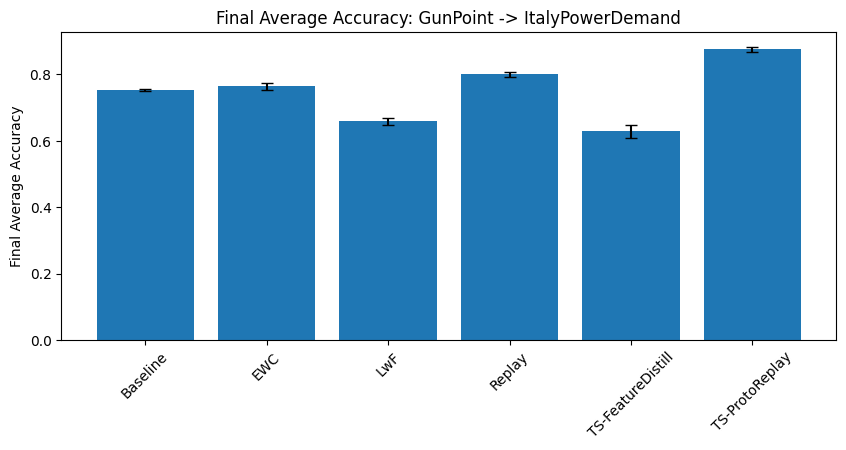

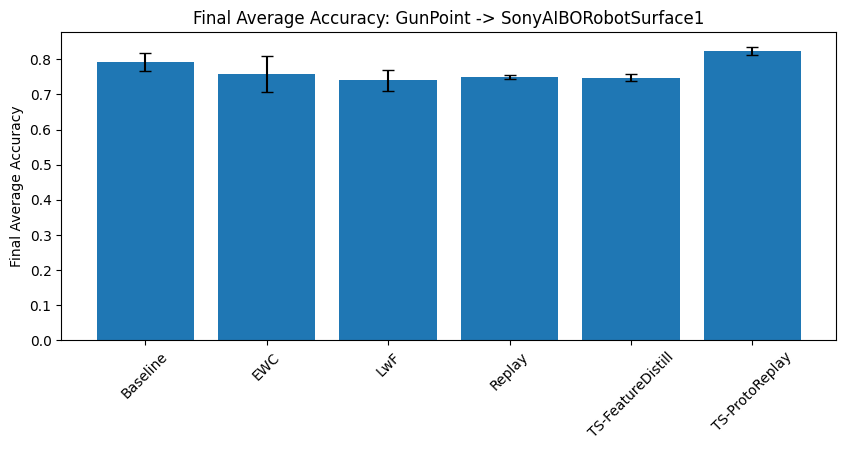

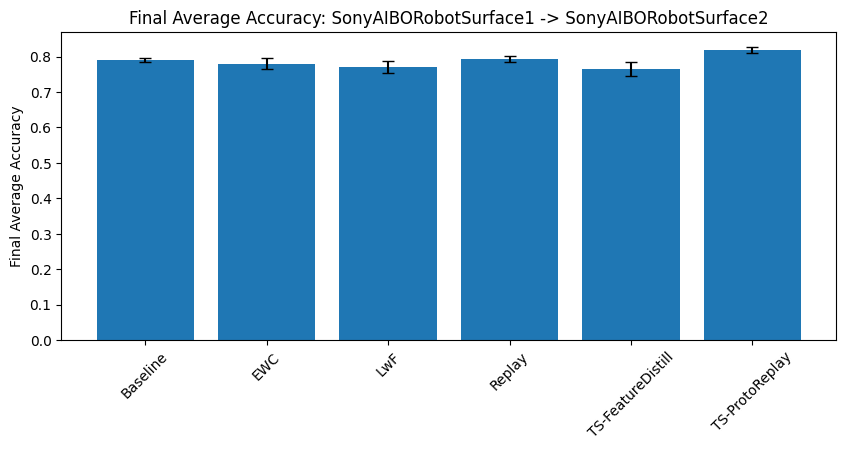

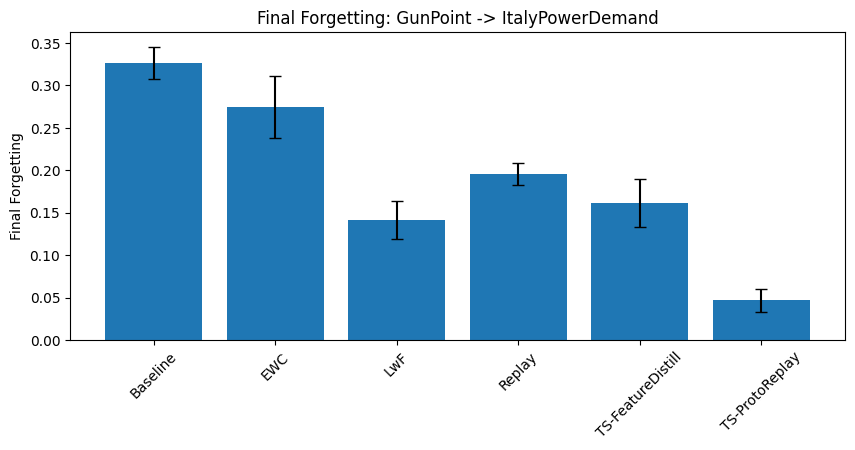

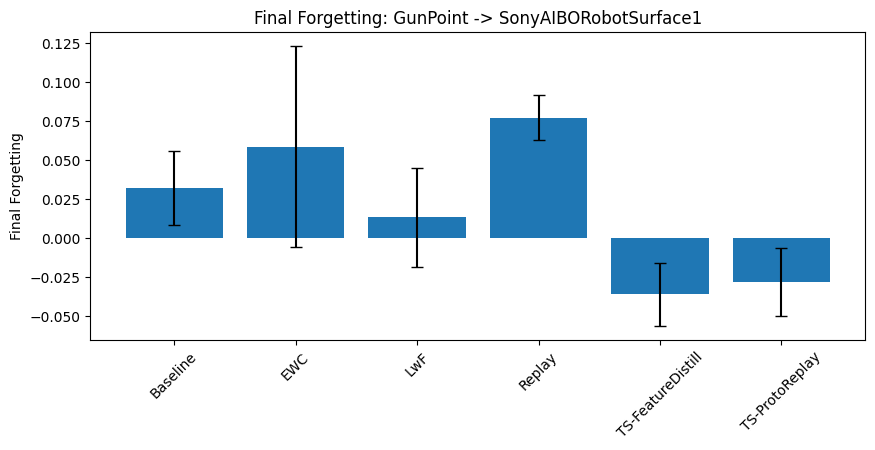

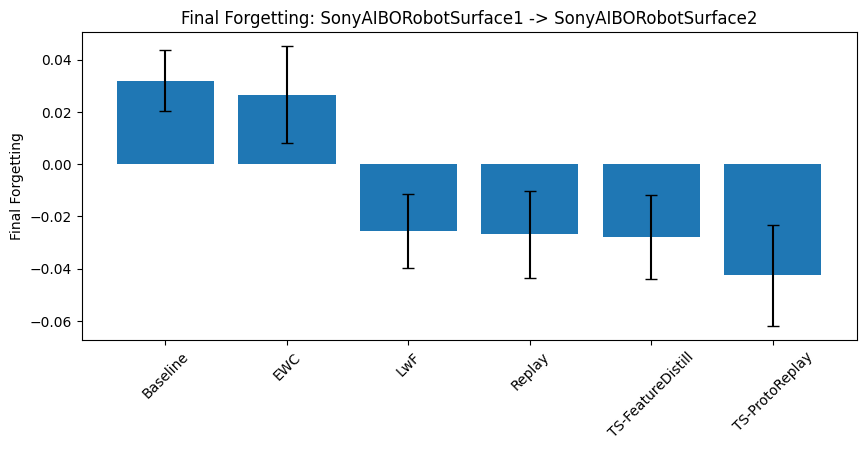

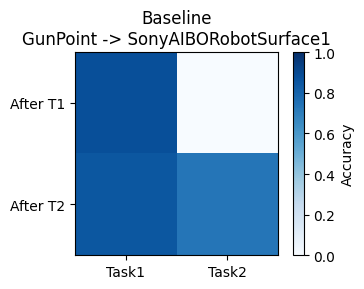

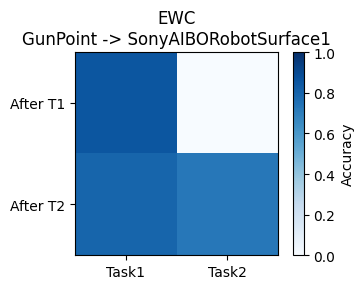

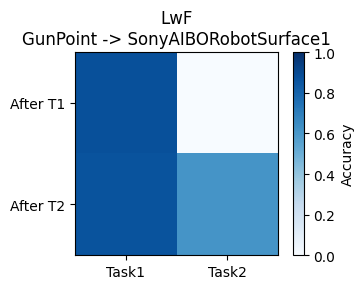

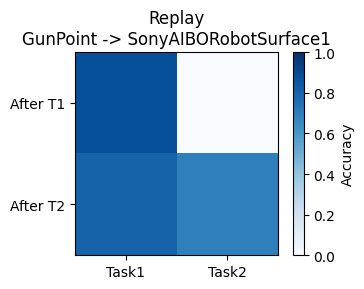

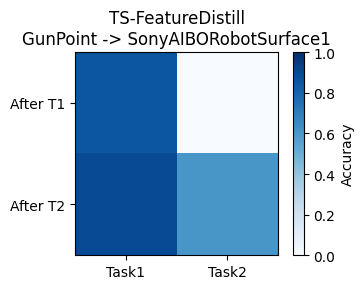

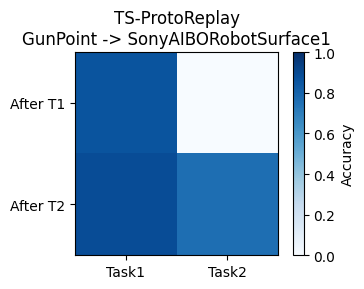

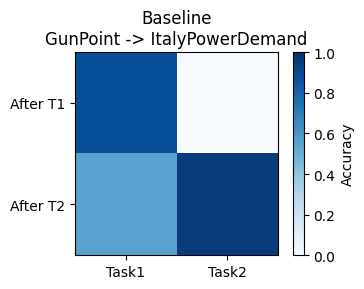

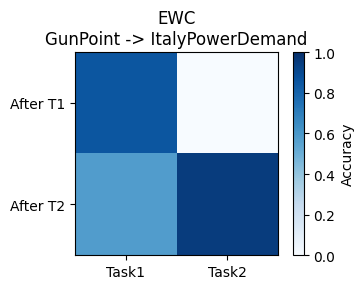

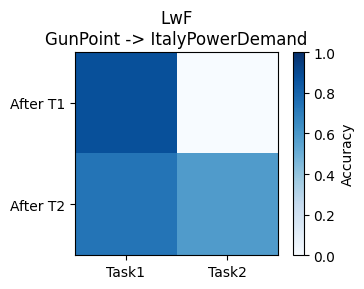

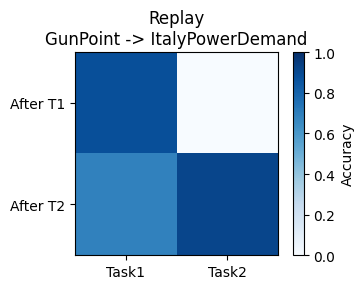

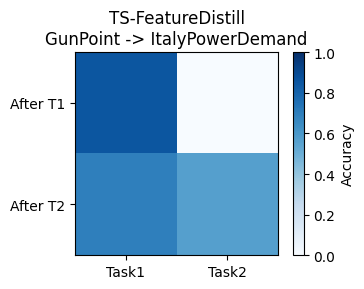

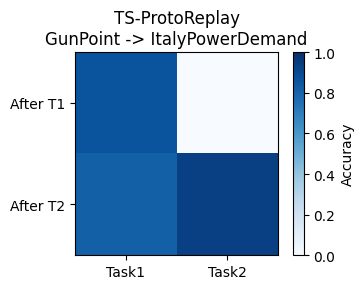

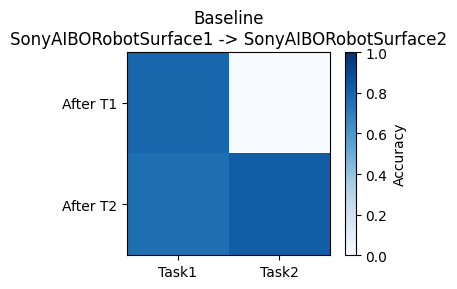

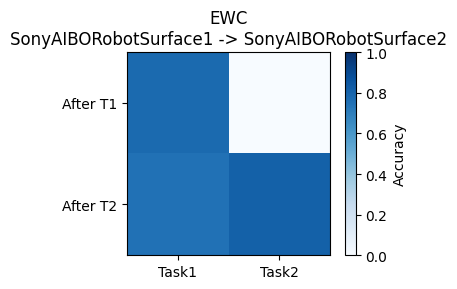

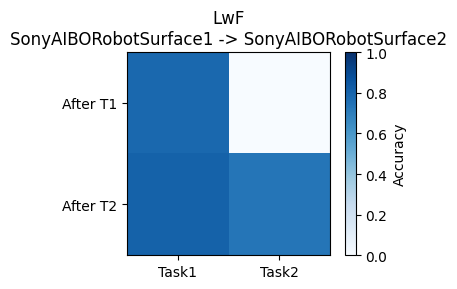

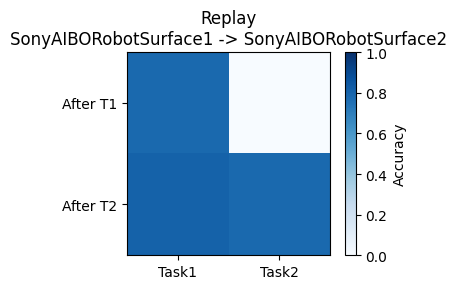

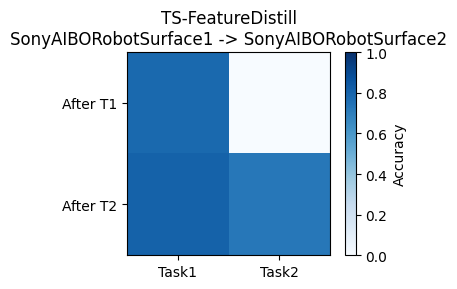

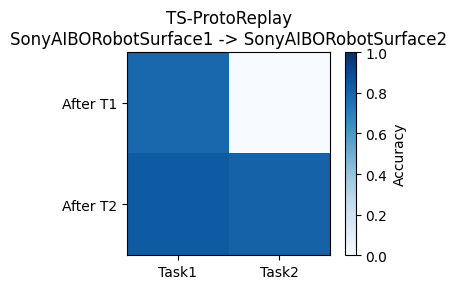

In [ ]:
# ============================================================
# 24) Plot results
# ============================================================
plot_sequence_results(agg_df, metric="final_avg_acc_mean")
plot_sequence_results(agg_df, metric="final_forgetting_mean")

plot_mean_accuracy_matrices(mat_agg, [" -> ".join(seq) for seq in SEQUENCES])

In [ ]:
# ============================================================
# 25) Ranked views
# ============================================================
print("\n=== Ranked by Final Average Accuracy ===")
display(rank_methods(agg_df, by="final_avg_acc_mean", ascending=False))

print("\n=== Ranked by Final Forgetting ===")
display(rank_methods(agg_df, by="final_forgetting_mean", ascending=True))


=== Ranked by Final Average Accuracy ===


,sequence,method,final_avg_acc_mean,final_avg_acc_std,final_forgetting_mean,final_forgetting_std
5,GunPoint -> ItalyPowerDemand,TS-ProtoReplay,0.875458,0.007896,0.046667,0.013333
3,GunPoint -> ItalyPowerDemand,Replay,0.800004,0.007527,0.196000,0.012996
1,GunPoint -> ItalyPowerDemand,EWC,0.764760,0.010545,0.274667,0.036332
0,GunPoint -> ItalyPowerDemand,Baseline,0.753232,0.002626,0.326667,0.018856
2,GunPoint -> ItalyPowerDemand,LwF,0.658657,0.010552,0.141333,0.022311
4,GunPoint -> ItalyPowerDemand,TS-FeatureDistill,0.628397,0.020532,0.161333,0.028048
11,GunPoint -> SonyAIBORobotSurface1,TS-ProtoReplay,0.824201,0.011804,-0.028000,0.021807
6,GunPoint -> SonyAIBORobotSurface1,Baseline,0.791555,0.025898,0.032000,0.023758
7,GunPoint -> SonyAIBORobotSurface1,EWC,0.758064,0.050716,0.058667,0.064533
9,GunPoint -> SonyAIBORobotSurface1,Replay,0.748256,0.005686,0.077333,0.014606



=== Ranked by Final Forgetting ===


,sequence,method,final_avg_acc_mean,final_avg_acc_std,final_forgetting_mean,final_forgetting_std
5,GunPoint -> ItalyPowerDemand,TS-ProtoReplay,0.875458,0.007896,0.046667,0.013333
2,GunPoint -> ItalyPowerDemand,LwF,0.658657,0.010552,0.141333,0.022311
4,GunPoint -> ItalyPowerDemand,TS-FeatureDistill,0.628397,0.020532,0.161333,0.028048
3,GunPoint -> ItalyPowerDemand,Replay,0.800004,0.007527,0.196000,0.012996
1,GunPoint -> ItalyPowerDemand,EWC,0.764760,0.010545,0.274667,0.036332
0,GunPoint -> ItalyPowerDemand,Baseline,0.753232,0.002626,0.326667,0.018856
10,GunPoint -> SonyAIBORobotSurface1,TS-FeatureDistill,0.747996,0.009250,-0.036000,0.020331
11,GunPoint -> SonyAIBORobotSurface1,TS-ProtoReplay,0.824201,0.011804,-0.028000,0.021807
8,GunPoint -> SonyAIBORobotSurface1,LwF,0.740487,0.030181,0.013333,0.031972
6,GunPoint -> SonyAIBORobotSurface1,Baseline,0.791555,0.025898,0.032000,0.023758
